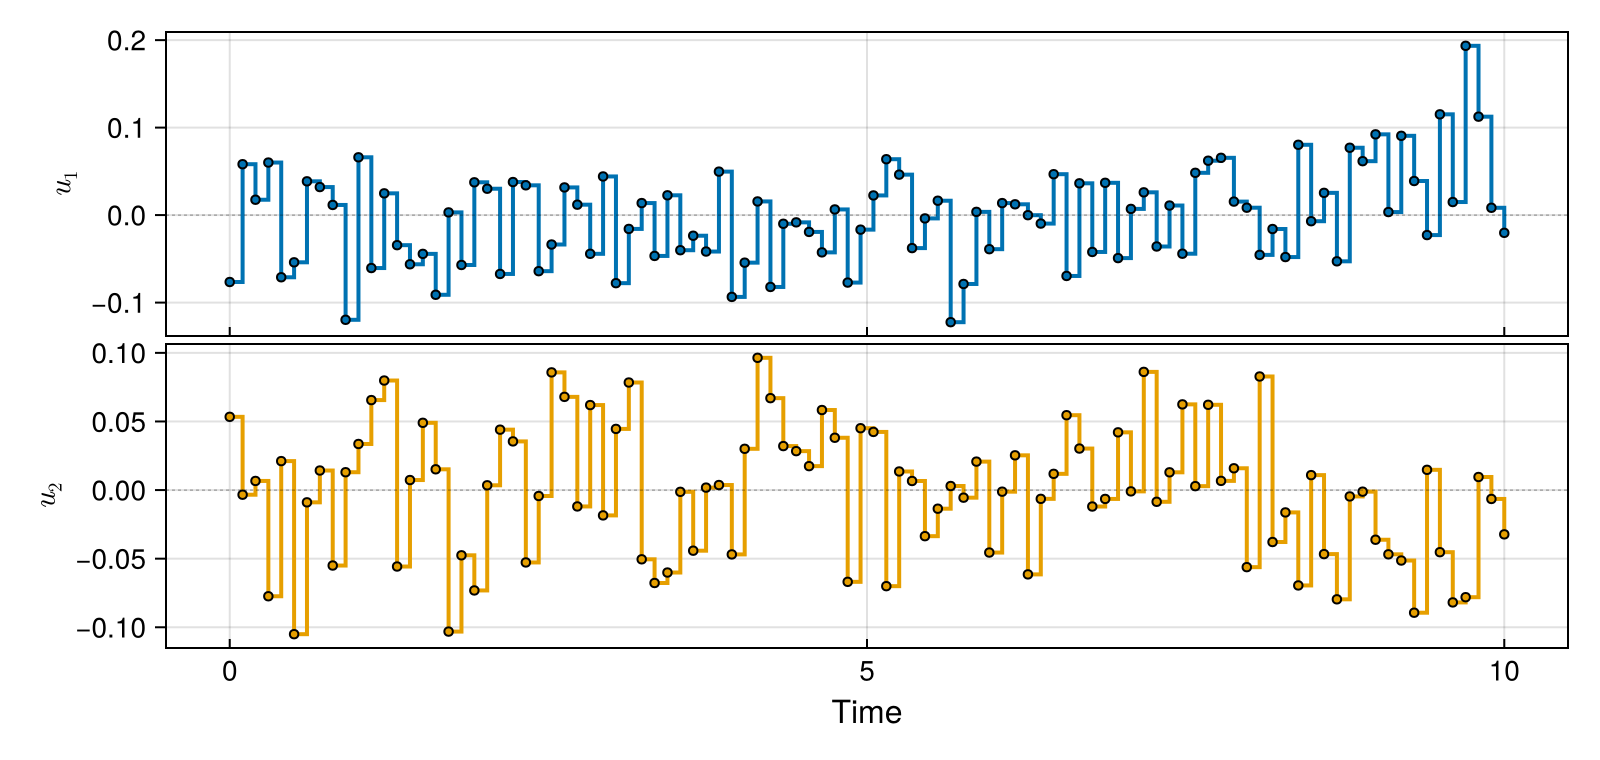

In [1]:
using Piccolo
using CairoMakie
using Random

# 1. Create multilevel system
sys = TransmonSystem(levels = 3, δ = 0.2, drive_bounds = [0.15, 0.15])

# 2. Define embedded gate
U_goal = EmbeddedOperator(:X, sys)

# 3. Create trajectory
T, N = 10.0, 100
times = collect(range(0, T, length = N))
pulse = ZeroOrderPulse(0.05 * randn(2, N), times)
qtraj = UnitaryTrajectory(sys, pulse, U_goal)

plot_pulse(qtraj; fig_size = (900, 700))


In [2]:
# 4. Configure leakage suppression
opts = PiccoloOptions(
    leakage_cost = 5.0,
    leakage_constraint = true,
    leakage_constraint_value = 1e-3,
    display = :silent,
)

PiccoloOptions(:silent, false, ExponentialAction.expv, true, false, nothing, 1.0, true, false, true, 0.001, 5.0)

In [7]:
# 5. Solve
qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, piccolo_options = opts)
solve!(
    qcp;
    max_iter = 150,
    verbose = false,
    print_level = 5,
    eval_hessian=false
)


qcp_noleakage_correction = SmoothPulseProblem(qtraj, N; Q = 100.0)
solve!(
    qcp_noleakage_correction;
    max_iter = 150,
    verbose = false,
    print_level = 5,
    eval_hessian=false
)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:   113046
Number of nonzeros in inequality constraint Jacobian.:     7074
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2577
                     variables with only lower bounds:      100
                variables with lower and upper bounds:     2178
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2277
Total number of inequality constraints...............:      800
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      800

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.8048074e+01 5.07e-01 1.59e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.15, 0.15]                   ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 60.65  @ current x
│    KnotPointObjective           w=1             59.19
│    QuadraticRegularizer(:u)     w=1             2.644e-05
│    QuadraticRegularizer(:du)    w=1             5.191e-03
│    QuadraticRegularizer(:ddu)   w=1             1.453
│    NullObjective                w=1     

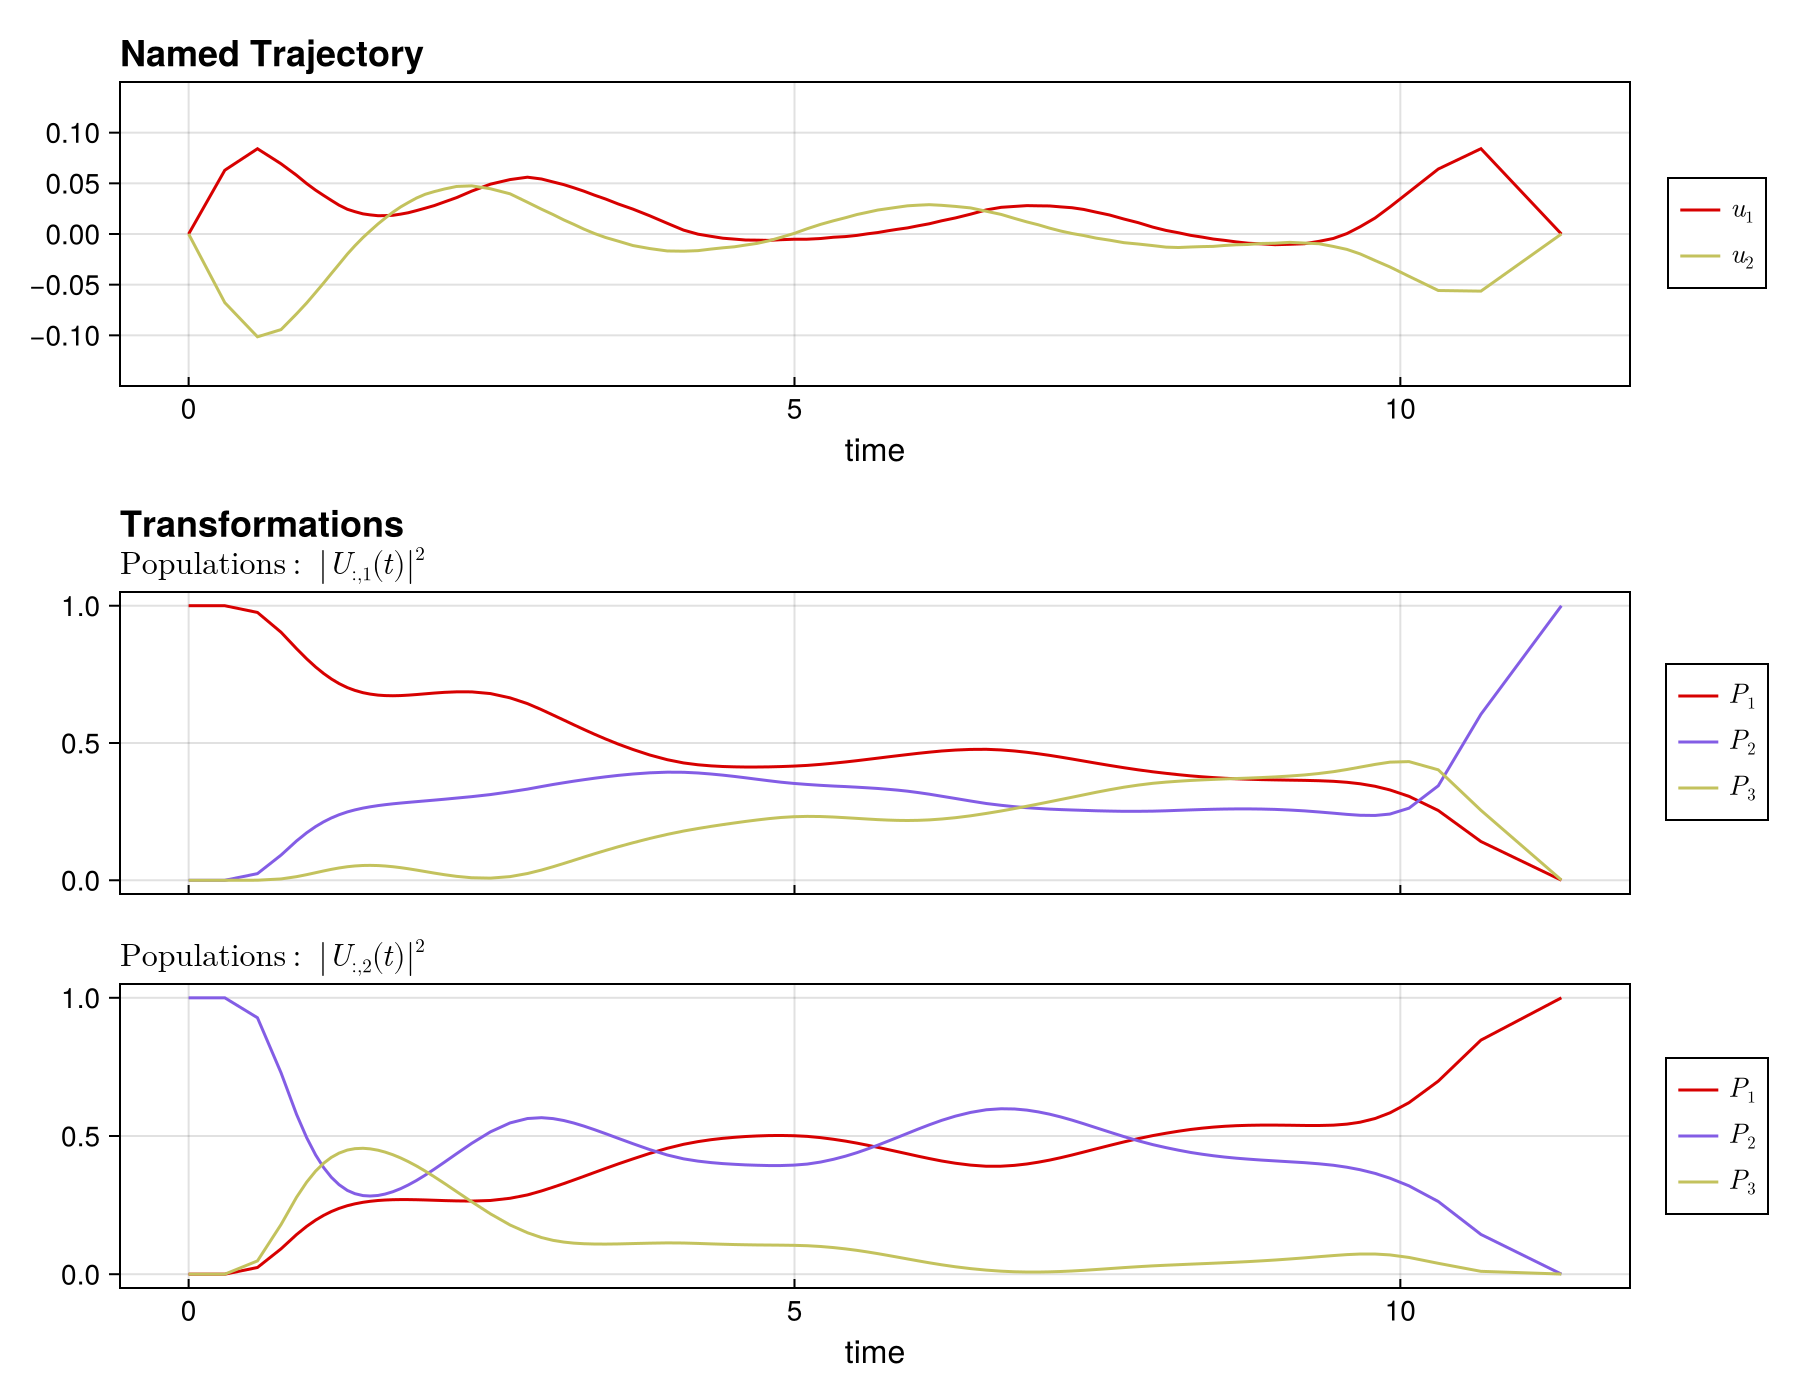

In [18]:

T, N = 10.0, 100
times = collect(range(0, T, length = N))
pulse = ZeroOrderPulse(0.05 * randn(2, N), times)
qtraj = UnitaryTrajectory(sys, pulse, U_goal)
qcp_noleakage_correction = SmoothPulseProblem(qtraj, N; Q = 100.0)
solve!(
    qcp_noleakage_correction;
    max_iter = 100,
    verbose = false,
    eval_hessian=false
)
plot_unitary_populations(get_trajectory(qcp_noleakage_correction); fig_size = (900, 700))

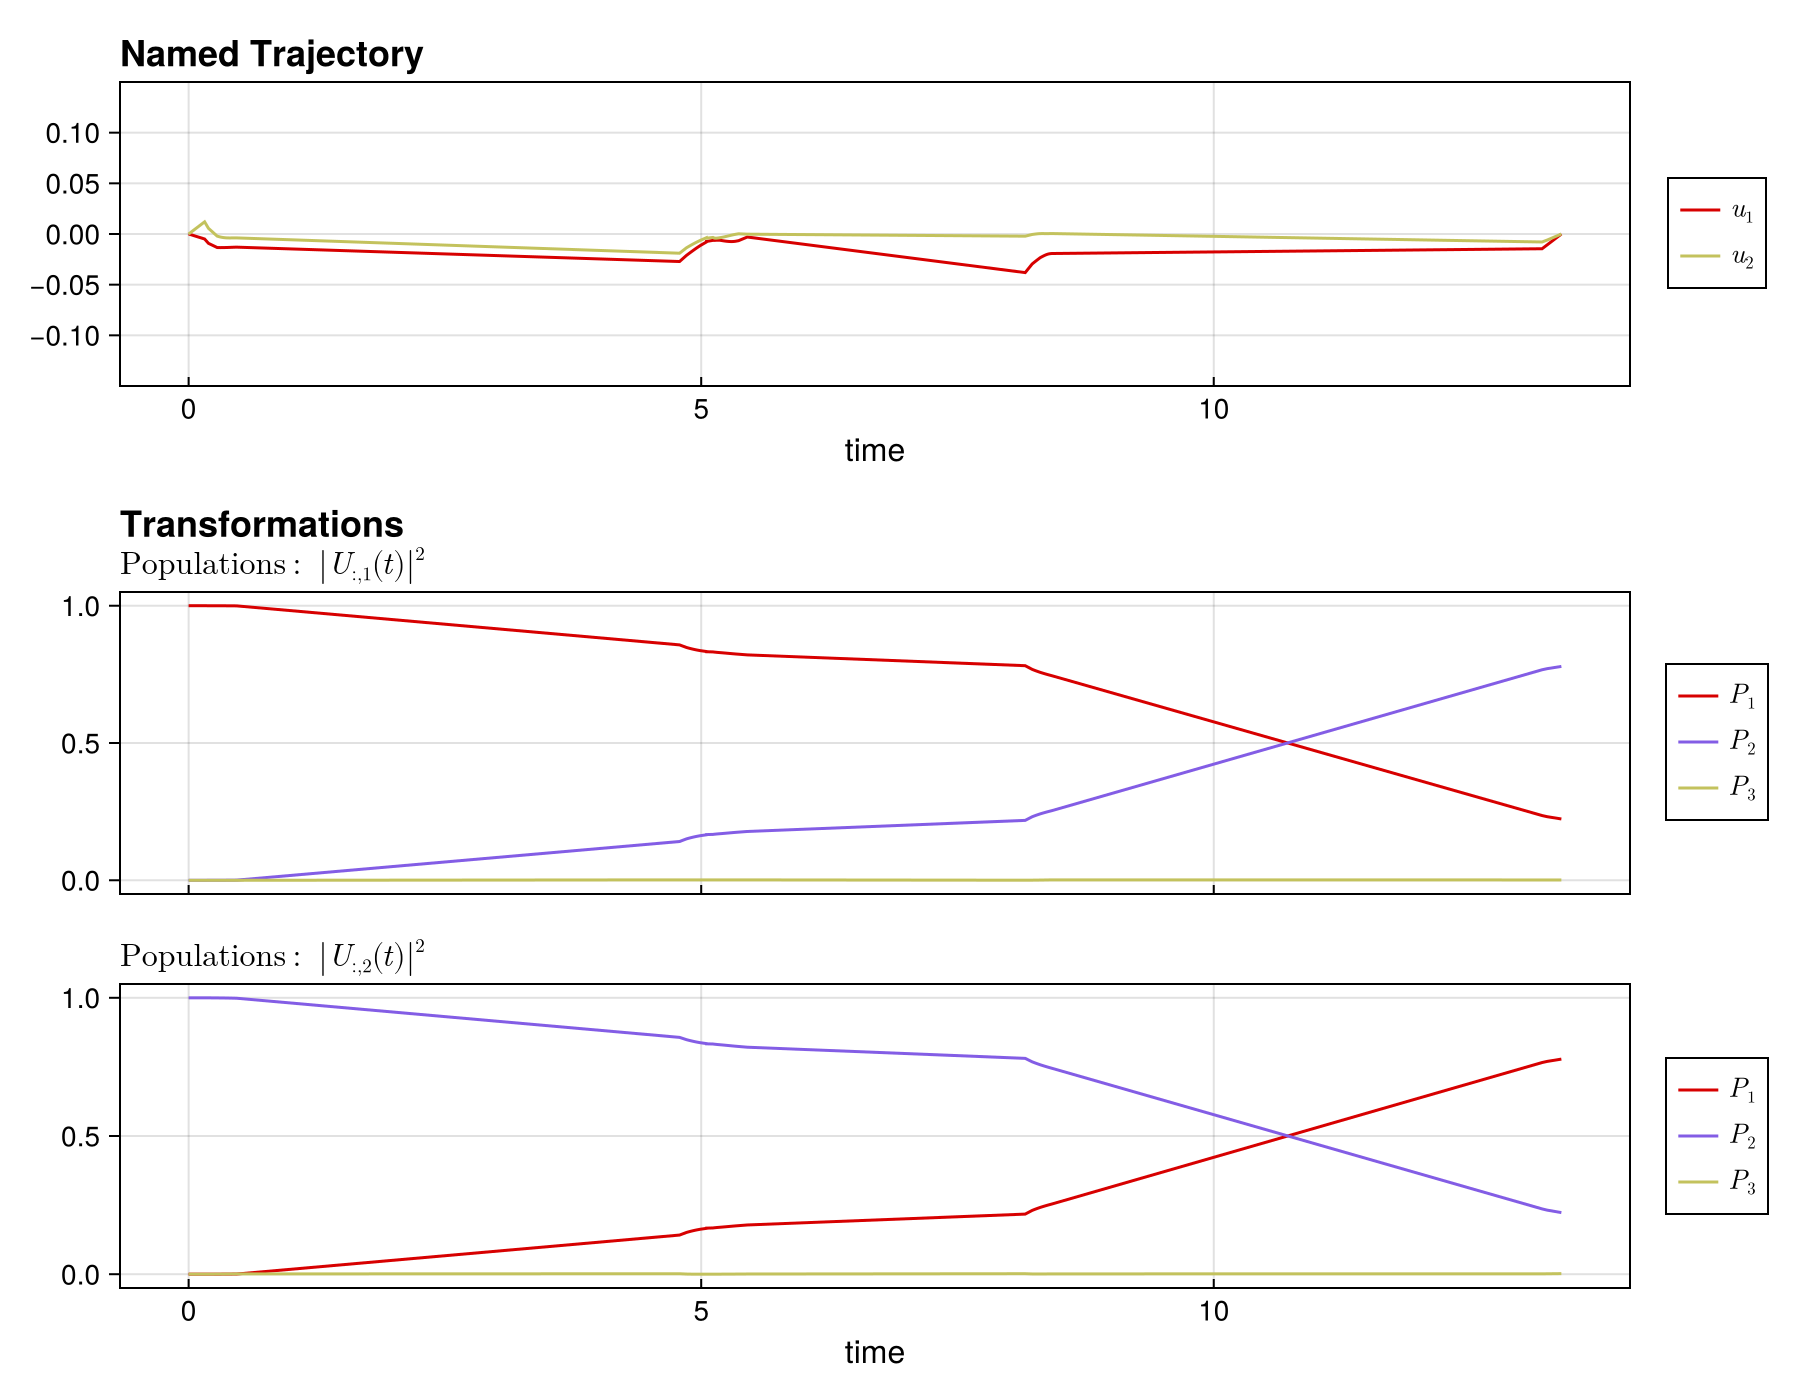

In [5]:
plot_unitary_populations(get_trajectory(qcp); fig_size = (900, 700))

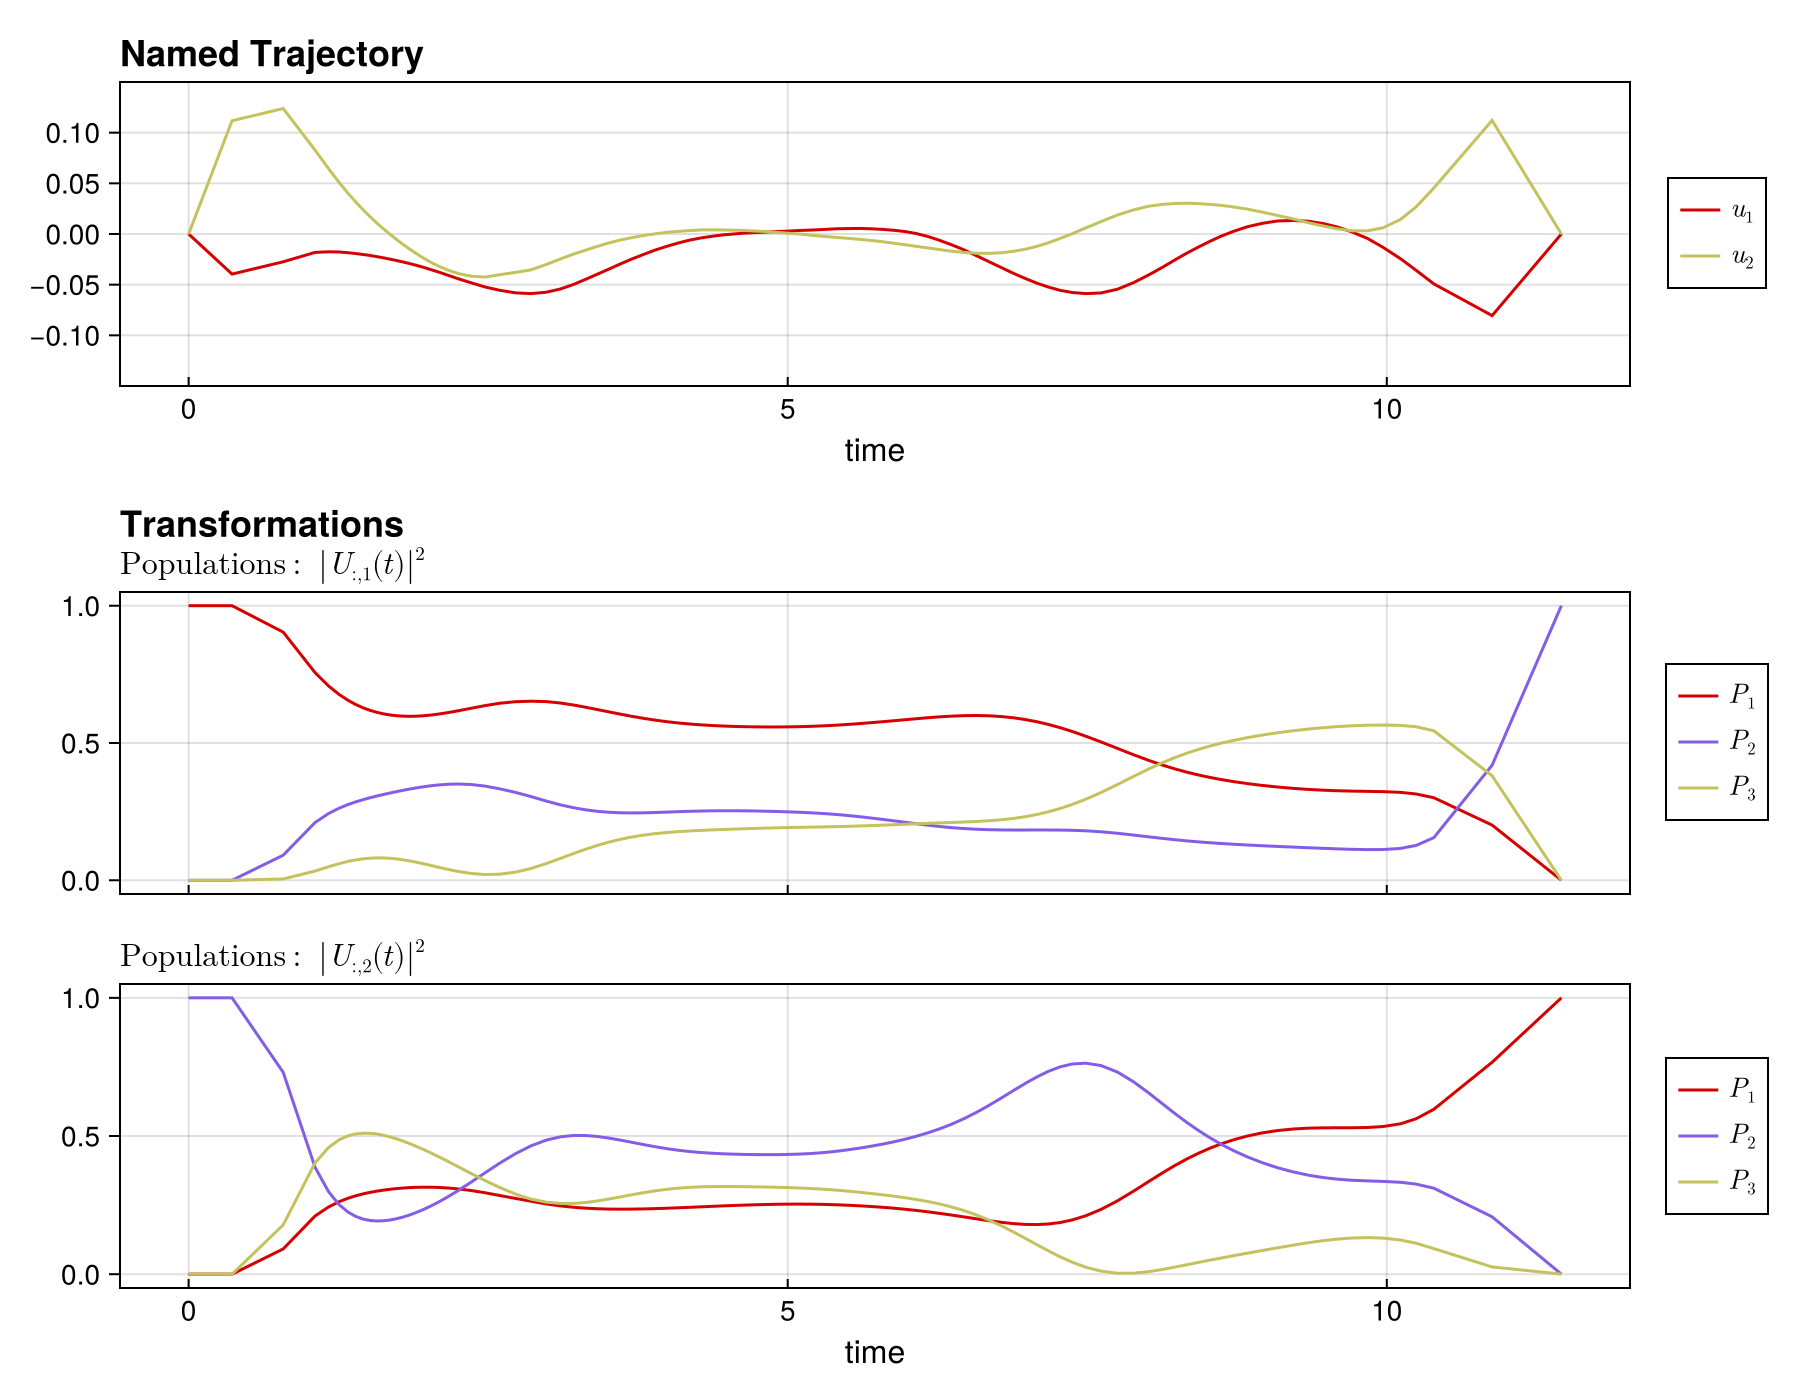

In [ ]:
plot_unitary_populations(get_trajectory(qcp_noleakage_correction); fig_size = (900, 700))

In [ ]:
sys_duffing = TransmonSystem(levels = 3, δ = 0.2, ω = 0.4, lab_frame_type = :duffing, drive_bounds = [0.2, 0.2])
#sys_cosine = TransmonSystem(levels = 3, δ = 0.2, lab_frame_type = :cosine, drive_bounds = [0.15, 0.15])

U_target = EmbeddedOperator(:X, sys_duffing)

println(fidelity(qcp))
println(fidelity(qcp_noleakage_correction))

qtraj_duffing = UnitaryTrajectory(sys_duffing, pulse, U_target)

# sys_duffing.H_drift
# sys_duffing.H_drives

# Leakage indices in isomorphic vector space
leak_indices = get_iso_vec_leakage_indices(U_target)
leak_indices

traj = get_trajectory(qcp)


0.9998729519149434
0.9998729519149434


In [ ]:
using Piccolo
using CairoMakie

function fidelity_full_transmon(levels, drive_bounds, T, iter, leakage_constraint::Bool = false,  δ = 0.2, N = 100)
    sys = TransmonSystem(levels = levels, δ = δ, drive_bounds = drive_bounds)
    U_goal = EmbeddedOperator(:X, sys)
    times = collect(range(0, T, length = N))
    pulse = ZeroOrderPulse(0.05 * randn(2, N), times)
    qtraj = UnitaryTrajectory(sys, pulse, U_goal)

    
    if leakage_constraint == false
        qcp = SmoothPulseProblem(qtraj, N; Q = 100.0)
    
    else
        qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, piccolo_options = opts)
    end
        solve!(
            qcp;
            max_iter = iter,
            verbose = false,
            print_level = 1,
            eval_hessian=false)
    return fidelity(qcp)
end


levels = 3
bound = [0.2, 0.2]
t = 10
iter = 150

opts = PiccoloOptions(
        leakage_cost = 5.0,
        leakage_constraint = true,
        leakage_constraint_value = 1e-3,
        display = :silent,
        )

fidelity_full_transmon(levels, bound, t, iter)



constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 61.92  @ current x
│    KnotPointObjective           w=1             60.48
│    QuadraticRegularizer(:u)     w=1             2.421e-05
│    QuadraticRegularizer(:du)    w=1             4.830e-03
│    QuadraticRegularizer(:ddu)   w=1             1.437
│    NullObjective                w=1     

0.9997551515748434

In [19]:
using Plots
using Piccolo
using CairoMakie
using ForwardDiff
using Symbolics

const Levels = 3
const Delta = 0.2
const Drive_bound = 0.5

sys = TransmonSystem(drive_bounds = [Drive_bound, Drive_bound], levels = Levels, δ = Delta)

U_goal = EmbeddedOperator(:X, sys) #X gate acting on |0>,|1> computational subspace

#intgrate a fucntion over [0,tg] with trapezoid rule used to claobrate the pulse area 
function trapezoid(f, tg, n=2000)
    ts = range(0, tg; length = n)
    ys = f.(ts)
    dt = tg/(n-1)

    #timespan
    #find y each t value
    #dt is width of each step
    return dt * (sum(ys)- 0.5*(ys[1] + ys[end]))

end

function gaussian_pulse(tg; sigma_frac = 0.5) # are aclaibrates the mplitude to pi(for X Gate)
    sigma = sigma_frac*tg
    shape(t) = exp(-(t-tg/2)^2/(2*sigma^2))
    area_unit = trapezoid(shape, tg)
    A = pi/area_unit
    return GaussianPulse([A,0.0],sigma,tg;center = tg/2)
end

function drag_pulse(tg,Δ;sigma_frac = 0.5, beta = 1.0)
    sigma = sigma_frac*tg
    shape(t)= exp(-(t-tg/2)^2/(2*sigma^2))
    dshape(t) = -(t-tg/2)/sigma^2*shape(t)

    area_unit = trapezoid(shape,tg)
    A = pi/area_unit

    f = t -> begin
        if t< 0 || t>tg
            return [0.0,0.0]
        end
        Ωx = A * shape(t)
        Ω_drag = im*(beta/Δ)*dshape(t)
        return [Ωx,Ω_drag]
    end
    return FunctionPulse(f,tg,2)
end

function gate_error(pulse,tg)
    qtraj = UnitaryTrajectory(sys,pulse, U_goal)
    out = rollout(qtraj)
    return 1-fidelity(out)
end

function optimized_error(tg, Δ; N = 100,max_iter =150)
    drag = drag_pulse(tg, Δ)
    times = collect(range(0,tg,length =N))
    ctrl = hcat([drag(t) for t in times]...)
    
    #ctrl is causing the error 
    #Ugoal is never taken in
    qtraj = UnitaryTrajectory(sys,ZeroOrderPulse(ctrl, times), U_goal)
    qcp = SmoothPulseProblem(qtraj,N; Q =100.0, R = 1e-3)
    solve!(qcp; max_iter =max_iter, print_level = 1, eval_hessian = false)
    return 1 - fidelity(qcp)
end


optimized_error (generic function with 1 method)

FunctionPulse(Number of drives = 2, T = 3.0)
FunctionPulse(Number of drives = 2, T = 3.5)
FunctionPulse(Number of drives = 2, T = 4.0)
FunctionPulse(Number of drives = 2, T = 4.5)
FunctionPulse(Number of drives = 2, T = 5.0)
FunctionPulse(Number of drives = 2, T = 5.5)
FunctionPulse(Number of drives = 2, T = 6.0)
FunctionPulse(Number of drives = 2, T = 6.5)
FunctionPulse(Number of drives = 2, T = 7.0)
FunctionPulse(Number of drives = 2, T = 7.5)
FunctionPulse(Number of drives = 2, T = 8.0)
FunctionPulse(Number of drives = 2, T = 8.5)
FunctionPulse(Number of drives = 2, T = 9.0)
Saved


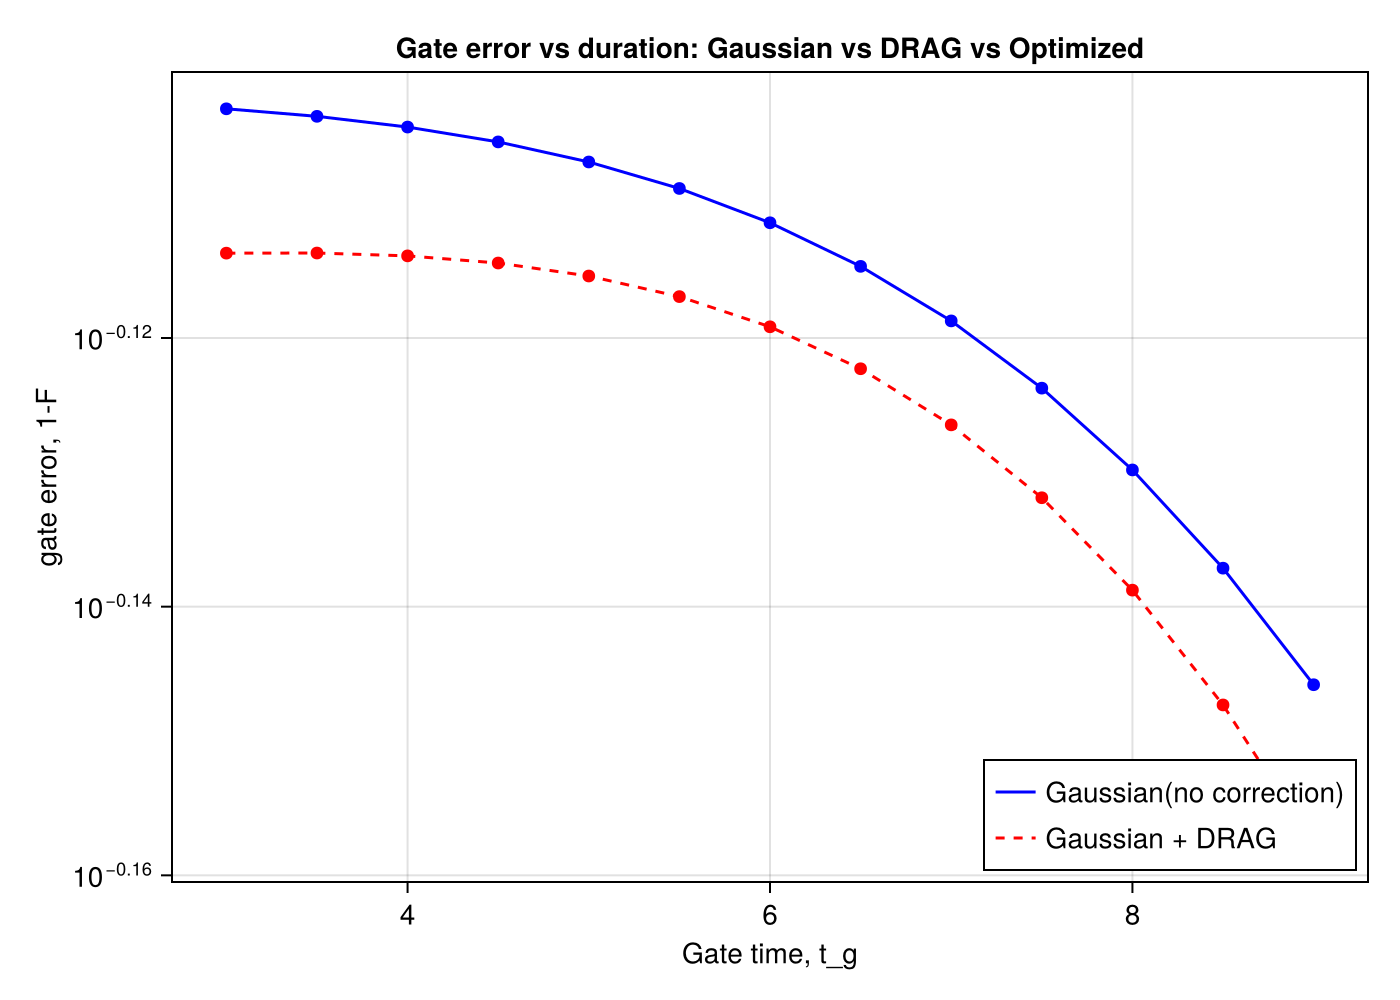

In [ ]:
gate_times = collect(range(3.0,9.0,length=13))
Δ = 2*pi

err_gauss = Float64[]
err_drag = Float64[]
err_opt = Float64[]

for tg in gate_times
    push!(err_gauss, gate_error(gaussian_pulse(tg),tg))
    push!(err_drag, gate_error(drag_pulse(tg,Δ),tg))
    #push!(err_opt, optimized_error(tg,Δ))
end
# for tg in gate_times
#     #println(gaussian_pulse(tg))
#     #println(gate_error(gaussian_pulse(tg), tg))
#     println(drag_pulse(tg, Δ))
# end

fig = Figure(size = (700,500))
ax = Axis(fig[1, 1], 
    xlabel = "Gate time, t_g", 
    ylabel = "gate error, 1-F", 
    yscale = log10, 
    title = "Gate error vs duration: Gaussian vs DRAG vs Optimized")

lines!(ax, gate_times, err_gauss, label = "Gaussian(no correction)", color =:blue)
CairoMakie.scatter!(ax, gate_times, err_gauss, color=:blue)

lines!(ax,gate_times, err_drag, label = "Gaussian + DRAG", color =:red, linestyle = :dash)
CairoMakie.scatter!(ax,gate_times, err_drag, color=:red)

# lines!(ax,gate_times, err_opt, label = "Numerically optimized", color =:purple, linestyle = :dot)
# CairoMakie.scatter!(ax,gate_times, err_opt, color=:purple)

axislegend(ax,position = :rb)
display(fig)
#save("project1_gate_error_vs_duration",fig)

In [ ]:

using Piccolo
using SparseArrays
using Random; Random.seed!(123)
using CairoMakie
using LinearAlgebra
using Optim
const T0 = 10.0    
const N  = 50       
const dt = T0 / N
const times = collect(range(0, T0, length = N))

const LEVELS = 3
const DELTA  = 0.2   
const U_BOUND = [0.2, 0.2]
const DDU_BOUND = 1.0
const DRAG_SIGMA = T0 / 6
const DRAG_AMP   = pi/ (DRAG_SIGMA*sqrt(2pi)) 

I_env(t)  = DRAG_AMP * exp(-(t - T0/2)^2 / (2 * DRAG_SIGMA^2))
dI_env(t) = -((t - T0/2) / DRAG_SIGMA^2) * I_env(t)  

Q_env(t)  = -dI_env(t) / DELTA

drag_control(t) = [I_env(t), Q_env(t)]
     

In [32]:

const T = 20

function F(t)
    α = 0.598144
    A = π/(α*T)
    return A * (exp((-(t-T/2)^2)/2*(T/4)^2) - ℯ^2)
end



F (generic function with 2 methods)

In [ ]:
function gate_error(pulse,tg)
    qtraj = UnitaryTrajectory(sys,pulse, U_goal)
    out = rollout(qtraj)
    return 1-fidelity(out)
end

t_list = []
for i in range(1 10; length = 20)
    push!(t_list,i)
end
plot_unitary((F(t_list)); fig_size = (900, 700))

MethodError: MethodError: no method matching -(::Vector{Any}, ::Float64)
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::ChainRulesCore.NoTangent, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/IZ7FD/src/tangent_arithmetic.jl:61
  -(!Matched::ChainRulesCore.ZeroTangent, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/IZ7FD/src/tangent_arithmetic.jl:101
  -(!Matched::SymbolicUtils.BasicSymbolicImpl.var"typeof(BasicSymbolicImpl)"{TreeReal}, ::Real)
   @ SymbolicUtils ~/.julia/packages/SymbolicUtils/5gLBU/src/methods.jl:89
  ...
